# 05 -- Critical Materials

## Research Question
Which raw materials are genuinely supply-concentrated, and by how much -- using a transparent methodology, not an assumed list?

## Data
USGS Mineral Commodity Summaries 2025, World Data Release, 2023 world mine/refinery production by country. PUBLIC.

## Method
13 materials selected against four documented criteria (semiconductor relevance, EV/battery relevance, independently well-known concentration, Malaysia relevance -- see `python/cleaning/clean_critical_materials.py`). HHI, CR3, CR5 computed on each material's 2023 country-level production shares.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import sys, os
sys.path.insert(0, os.path.abspath('../python/visualisation'))
pd.set_option('display.max_columns', 20)

In [2]:
mat = pd.read_csv('../data/processed/critical_materials_concentration.csv').sort_values('HHI', ascending=False)
print(mat[['material','top_producer','top_producer_share_pct','HHI','CR3_pct']].round(1).to_string(index=False))

                     material     top_producer  top_producer_share_pct    HHI  CR3_pct
                      Gallium            China                    98.1 9625.8     99.5
                     Tungsten            China                    84.4 7166.2     91.5
                     Graphite            China                    78.9 6314.3     89.7
                       Cobalt Congo (Kinshasa)                    75.6 5822.2     87.6
                      Silicon            China                    71.8 5283.2     84.9
                  Rare earths            China                    68.1 4911.9     90.6
                       Nickel        Indonesia                    59.6 3837.4     78.5
           Aluminum (refined)            China                    59.2 3794.6     80.6
                      Lithium        Australia                    45.0 2823.4     82.8
             Copper (refined)            China                    49.0 2653.5     66.3
                    Manganese     South Afr

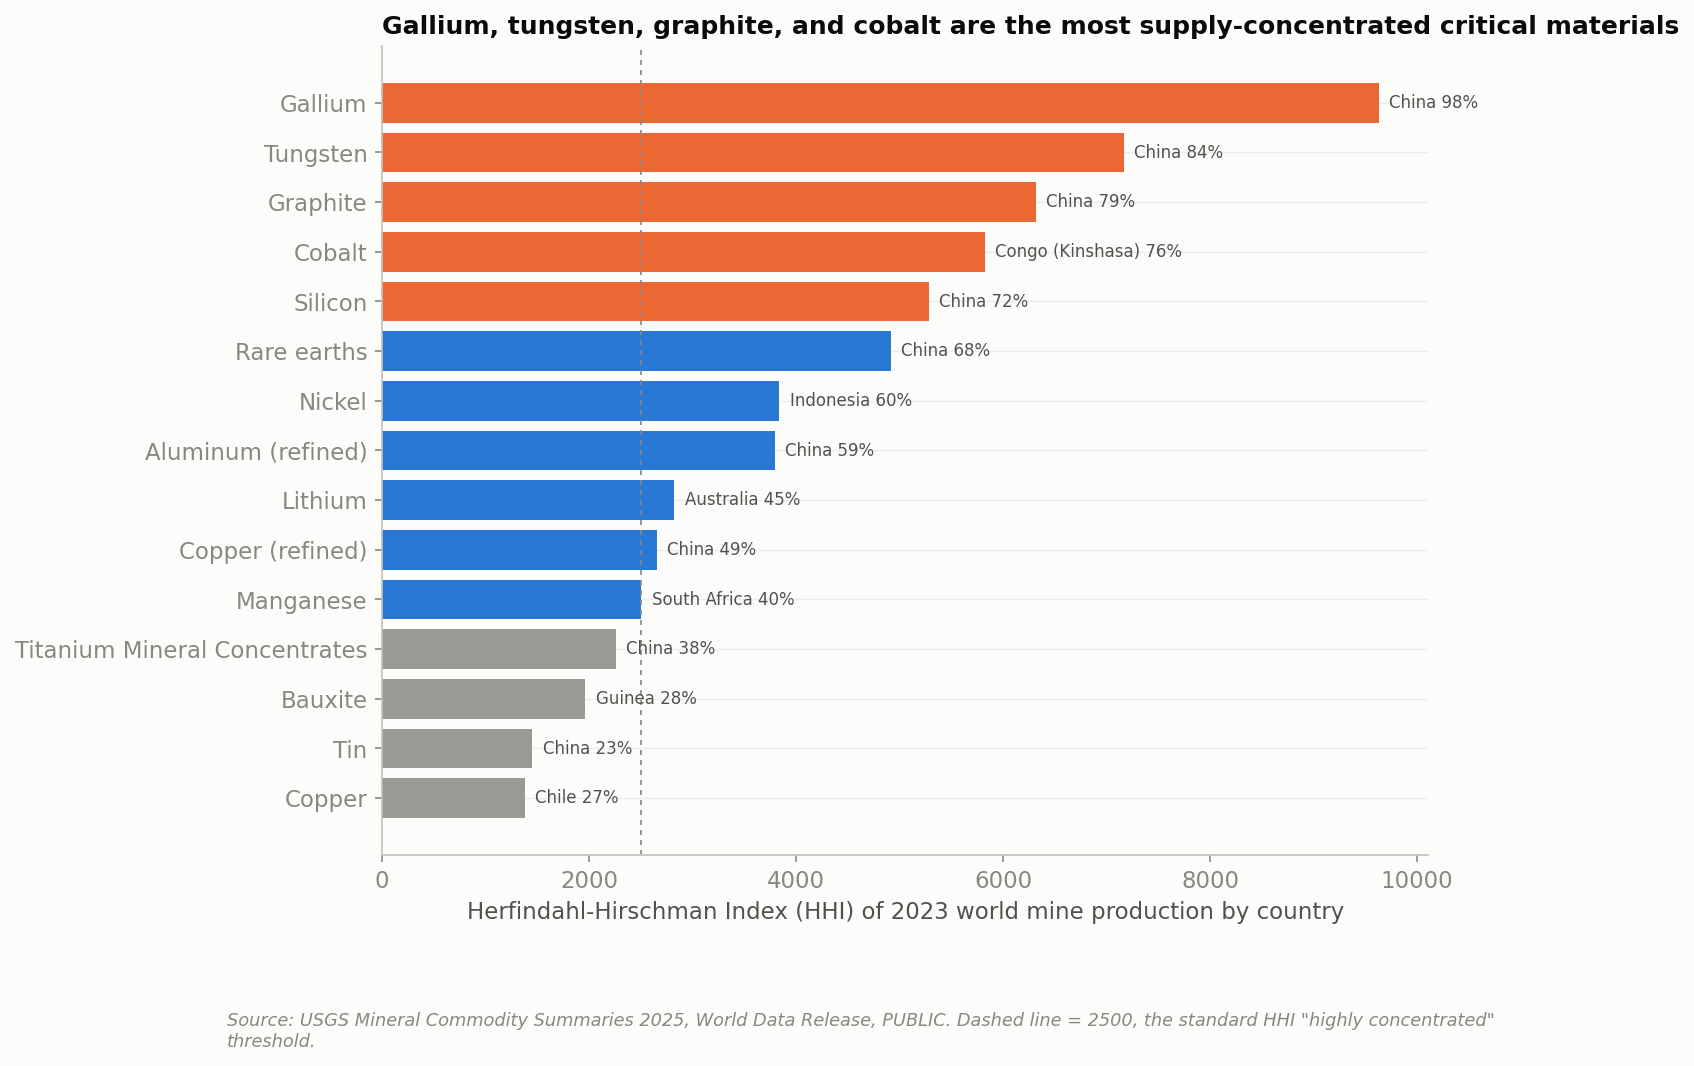

In [3]:
display(Image('../outputs/figures/06_critical_material_concentration.png', width=750))

## Finding

Four materials sit far above the standard "highly concentrated" HHI threshold of 2,500: Gallium (China, 98%), Tungsten (China, 84%), Graphite (China, 79%), and Cobalt (DR Congo, 76%). This matches -- and is independently confirmed by -- real, well-documented recent events (China's 2023-2025 gallium and graphite export licensing actions). Nickel (Indonesia, 60% and rising) is the clearest live case of concentration currently building, tied to Indonesia's real export/downstreaming policy.

A real data-quality bug was caught and fixed while building this table: the source file's COUNTRY column mixes genuine countries with 11 distinct "World total" label variants, which an early exclusion pass missed, wrongly ranking "World total" as every material's #1 producer at ~50% share -- see `docs/DATA_QUALITY.md` item 4 for the full story.

## Limitation

Refining/processing concentration (captured for Copper and Bauxite/Aluminum specifically, where the source reports both mine and refinery production) can differ sharply from mine-production concentration -- most famously cobalt, where DRC dominates mining but China dominates refining, a distinction this project's 13-material table only partially captures (2 of 13 have both stages).

## Next Step

Notebook 06 asks which countries are the most important *nodes* in the trade network carrying these and other goods.